## Cosmetic Shop: Time to Next Purchase 

Setup and Load

In [54]:
import duckdb 
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from src.survival import collapse_to_occurrences, assign_censoring
conn = duckdb.connect()

PARQUET_PATH = Path("../data/processed/master_events.parquet").as_posix()
PURCHASE_PATH = Path("../data/processed/purchases.parquet").as_posix()


In [55]:
purchases = pd.read_parquet(PURCHASE_PATH)
purchases

,event_time,product_id,category_id,category_code,brand,price,is_refund,user_id,user_session
0,2019-10-01 00:06:35,5814822,1487580005897601916,None,runail,2.38,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
1,2019-10-01 00:06:35,5875317,2029082628195353599,None,None,1.59,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
2,2019-10-01 00:06:35,5619862,1487580006895846315,None,runail,5.32,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
3,2019-10-01 00:06:35,5619866,1487580006895846315,None,runail,2.86,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
4,2019-10-01 00:06:35,5696184,1487580005134238553,None,runail,2.38,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
...,...,...,...,...,...,...,...,...,...
1286989,2020-02-29 23:46:01,5742957,1487580009387261981,None,None,3.81,0,620865261,64389dba-26c4-f328-6972-166a48654eaa
1286990,2020-02-29 23:54:44,5929649,1487580006350586771,appliances.environment.vacuum,max,95.08,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e
1286991,2020-02-29 23:54:44,5692863,1487580007910867929,None,yoko,7.83,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e
1286992,2020-02-29 23:54:44,5802432,1487580009286598681,None,None,0.32,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e


In [56]:
occasions = collapse_to_occurrences(purchases)
occasions

,user_session,user_id,occasion_time,has_refund,n_items
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10-23 11:12:21,0,9
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10-02 04:52:23,0,10
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02-15 09:11:59,0,4
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10-05 09:59:22,0,6
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12-14 09:01:26,0,5
...,...,...,...,...,...
155611,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,2019-12-24 07:20:04,0,9
155612,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,2020-02-21 20:02:10,0,5
155613,ffff8529-58c1-4ec8-933e-77f535718061,559782512,2019-10-13 12:12:17,0,6
155614,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,2020-02-12 08:28:55,0,2


In [57]:
dataset_end = purchases['event_time'].max()
occasions = assign_censoring(occasions, dataset_end)
occasions

,user_session,user_id,occasion_time,has_refund,n_items,next_occasion_time,days_to_next_purchase,censored,duration_days
29815,30d70cc3-86ee-4b5d-879c-40f06132163c,9794320,2019-11-25 05:07:13,0,4,NaT,NaN,1,96.782998
151170,f873d16b-4efa-4e92-81be-92948aef2ff5,10079204,2019-11-06 10:43:30,0,2,NaT,NaN,1,115.549468
114623,bcc9bfa0-8a71-485d-b315-297b0038b4c2,10280338,2019-11-20 18:36:14,0,10,2019-11-21 11:31:09,0.704803,0,0.704803
114689,bce6164d-93ef-4d65-ae2f-7ee15552eae7,10280338,2019-11-21 11:31:09,0,6,2020-01-12 22:54:37,52.474630,0,52.474630
122638,c9cad2fe-9213-42c0-a68a-c329b62f394a,10280338,2020-01-12 22:54:37,0,1,2020-02-13 21:25:18,31.937975,0,31.937975
...,...,...,...,...,...,...,...,...,...
101238,a6c280be-ad01-413d-818e-a818f3ac3558,622065819,2020-02-29 22:29:19,0,4,NaT,NaN,1,0.059317
34522,389680bd-69c6-4364-b549-651f82f8ffce,622066161,2020-02-29 21:54:22,0,4,NaT,NaN,1,0.083588
89547,93a3b8e4-f726-4cdc-8d18-12d4c6f23b59,622067983,2020-02-29 22:33:37,0,10,NaT,NaN,1,0.056331
85888,8d85bde1-9586-4a39-a8ed-ecc59ea083a0,622069477,2020-02-29 22:05:30,0,1,NaT,NaN,1,0.075856


In [58]:
survival_input = occasions[
    ['user_id', 'user_session', 'occasion_time', 'n_items', 'has_refund', 'duration_days', 'censored']
].copy()

print(f"Total occasions: {len(survival_input):,}")
print(f"Censored: {survival_input['censored'].sum():,} ({survival_input['censored'].mean():.1%})")
print(f"Observed repurchases: {(survival_input['censored'] == 0).sum():,}")

survival_input.head(10)

Total occasions: 155,616
Censored: 110,518 (71.0%)
Observed repurchases: 45,098


,user_id,user_session,occasion_time,n_items,has_refund,duration_days,censored
29815,9794320,30d70cc3-86ee-4b5d-879c-40f06132163c,2019-11-25 05:07:13,4,0,96.782998,1
151170,10079204,f873d16b-4efa-4e92-81be-92948aef2ff5,2019-11-06 10:43:30,2,0,115.549468,1
114623,10280338,bcc9bfa0-8a71-485d-b315-297b0038b4c2,2019-11-20 18:36:14,10,0,0.704803,0
114689,10280338,bce6164d-93ef-4d65-ae2f-7ee15552eae7,2019-11-21 11:31:09,6,0,52.474630,0
122638,10280338,c9cad2fe-9213-42c0-a68a-c329b62f394a,2020-01-12 22:54:37,1,0,31.937975,0
55155,10280338,5a8ef64a-9215-4c88-ad5f-b3bab4e03fb3,2020-02-13 21:25:18,47,0,5.747373,0
91712,10280338,9728269f-2014-4d85-a95a-0dab99c4851e,2020-02-19 15:21:31,22,0,10.356400,1
92640,12055855,98b129c4-2ab1-4e89-8511-de4bf7f0d943,2019-12-20 12:05:29,4,0,71.492535,1
146510,12936739,f0f01819-3cf4-455c-a6e5-61d25867f9ea,2020-01-17 07:51:19,2,0,43.669039,1
72911,15400971,77f879cf-e087-4ef5-a0dd-36620a6d61a3,2019-12-13 12:32:31,3,0,78.473762,1


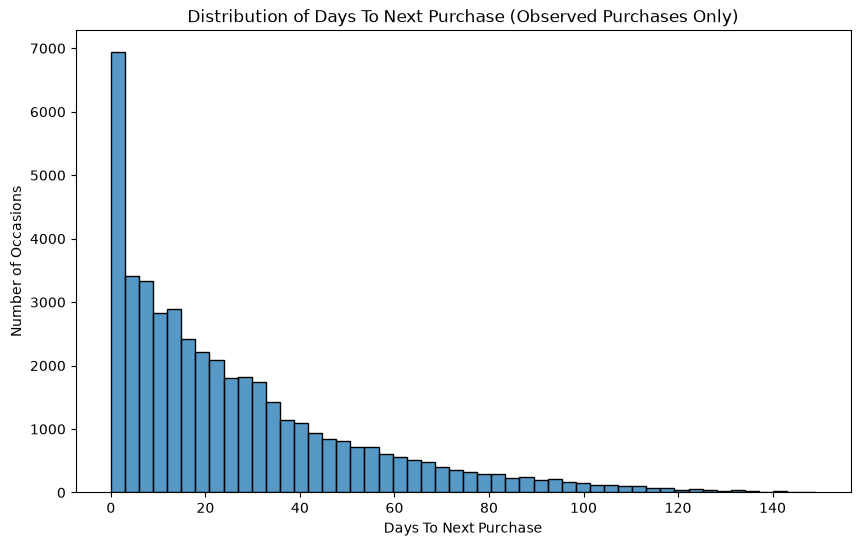

Median time to repurchase: 18.9 days

Additional Information:


count    45098.000000
mean        26.542000
std         26.071953
min          0.000000
25%          6.806377
50%         18.920862
75%         37.973941
max        149.059734
Name: duration_days, dtype: float64

In [59]:
uncensored = survival_input[survival_input['censored'] == 0]
plt.figure(figsize=(10,6))

sns.histplot(
    data = uncensored,
    x = 'duration_days',
    bins = 50
)

plt.title("Distribution of Days To Next Purchase (Observed Purchases Only)")
plt.xlabel("Days To Next Purchase")
plt.ylabel("Number of Occasions")

plt.show()

median_days = uncensored['duration_days'].median()
print(f"Median time to repurchase: {median_days:.1f} days")

print(f"\nAdditional Information:")
uncensored['duration_days'].describe()

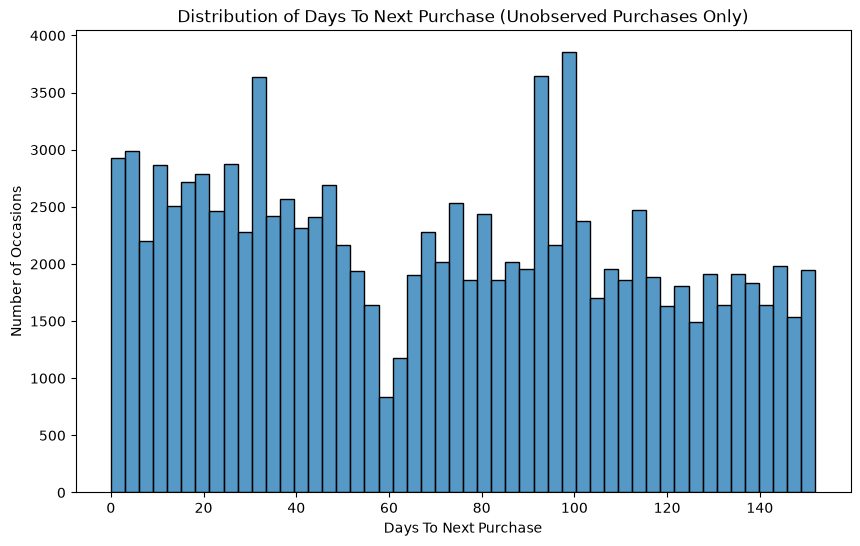

Median time Until Final Date in Data: 71.2 days

Additional Information:


count    110518.000000
mean         70.525855
std          43.965880
min           0.000000
25%          31.603015
50%          71.160052
75%         106.189063
max         151.989051
Name: duration_days, dtype: float64

In [60]:
censored = survival_input[survival_input['censored'] == 1]

plt.figure(figsize=(10,6))

sns.histplot(
    data = censored,
    x = 'duration_days',
    bins = 50
)

plt.title("Distribution of Days To Next Purchase (Unobserved Purchases Only)")
plt.xlabel("Days To Next Purchase")
plt.ylabel("Number of Occasions")

plt.show()


median_days = censored['duration_days'].median()
print(f"Median time Until Final Date in Data: {median_days:.1f} days")

print(f"\nAdditional Information:")
censored['duration_days'].describe()

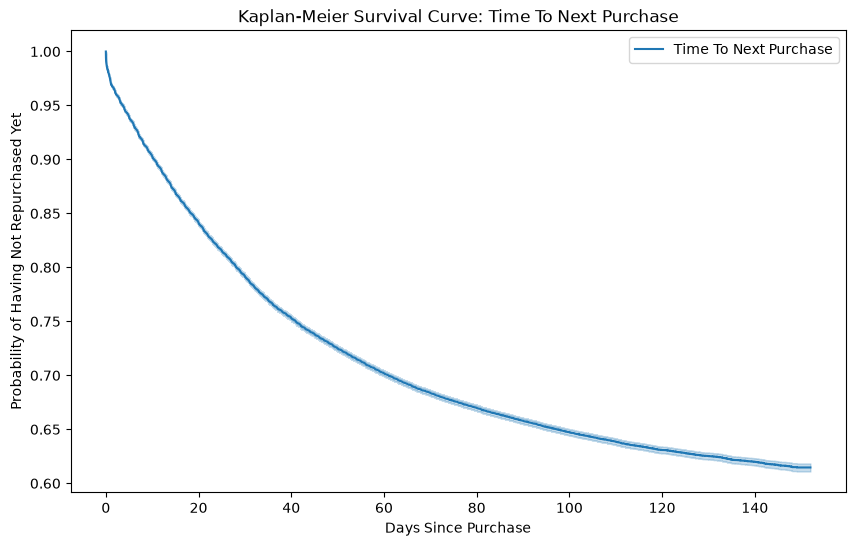

Median time to repurchase: inf days
By day  7: 7.6% of customers had repurchased
By day 14: 12.4% of customers had repurchased
By day 30: 20.8% of customers had repurchased
By day 60: 29.8% of customers had repurchased
By day 90: 34.2% of customers had repurchased


In [61]:
kmf = KaplanMeierFitter()
kmf.fit(
    durations = survival_input['duration_days'],
    event_observed = 1 - survival_input['censored'],
    label = 'Time To Next Purchase'
)

plt.figure(figsize=(10,6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve: Time To Next Purchase')
plt.xlabel('Days Since Purchase')
plt.ylabel('Probability of Having Not Repurchased Yet')
plt.show()

median_days = kmf.median_survival_time_
print(f"Median time to repurchase: {median_days:.1f} days")

for days in [7, 14, 30, 60, 90]:
    prob_not_repurchased = kmf.survival_function_at_times(days).values[0]
    print(f"By day{days:>3}: {1 - prob_not_repurchased:.1%} of customers had repurchased")

In [62]:
total_occasions = len(survival_input)
observed = (survival_input['censored'] == 0).sum()
censored = (survival_input['censored'] == 1).sum()

print(f"Total occasions: {total_occasions:,}")
print(f"Observed repurchases: {observed:,} ({observed/total_occasions:.1%})")
print(f"Censored: {censored:,} ({censored/total_occasions:.1%})")

Total occasions: 155,616
Observed repurchases: 45,098 (29.0%)
Censored: 110,518 (71.0%)


# Findings:

Across 155,616 purchases, there are 45,098 (29.0%) observed repurchases, with 110,518 (71.0%) single purchases by customers. 

Those 71.0% mean that we simply don't know when they will repurchase, not that they will will not.

Our 5-month dataset is limited; a clear sign of this is the infinite median of the time-to-repurchase median curve. The survival curve never crosses 50%, showing that repurchase activity takes longer to monitor than the 5-month window in this dataset. 

Our approach of using only uncensored data in a histogram (ignoring 71% of data) yielded a median of 18.9 days and a mean of 26.5 days, values that are biased low due to only reflecting customers that repurchased in a short 5-month window and eliminating slower repurchasers.

# What This Means

Most customers do not repurchase in a 5-month window

The distribution of customers who repurchased is right-skewed, concentrated in the first 20 days

# Limitations

71% censoring means that the tail of the survival curve is based on comparatively little data

Right censoring is structural and not due to data quality. It is a consequence of only having 5 months of data


# Next Steps

If a longer window of data becomes available, it is worth re-running these tests to see how the 71% censored results shift.

Segment re-purchase timing by category, price tier, or first-vs-repeat customer to see if the low observed repurchase rate 